# Description of models and priors in BEAST2 xml templates.

The BEAST 2 templates xmls for use with beast_pype are:
* [BDSKY-Serial](Measles_BDKSY-Serial.xml).
* [Coalescent Exponential](Measles_coalescent_exp.xml).

Data in these BEAST 2 templates xmls:
* Fasta/sequnces: `../data_and_xmls_from_Hiebert_2024/2023-03-01_56_WGS_D8.fas`.
* Date metadata : `../data_and_xmls_from_Hiebert_2024/2023-03-01_56_WGS_D8.tsv`.

**Note** these data sources have been kept in so these xmls can be loaded and altered  in BEAUti.

Importing packages:

In [1]:
import numpy as np
from scipy.stats import gamma
from matplotlib import pyplot as plt
from beast_pype.stat_distributions import gamma_from_mean


## Models & Priors shared between the template xmls.

### Strict Clock Model gamma distributed rate prior

From CL's notes:
''''
Assuming strict clock model is best for most viruses (especially without strong selection), and measles appears to be no different
Nextstrain's WGS time tree with 665 seqs from 1954 to present estimates 4.56x10-4 sub/site/yr, with slight variation if only run root to tip per genotype:

<img src="./measles_WGS_r2t_clock.png" width=50% height=50%>

[Joanne's paper](https://www.frontiersin.org/journals/microbiology/articles/10.3389/fmicb.2024.1475144/full): found B3 and D8 WGS clockrates around 5 to 6.19 x10-4 respectively

Other rates from the literature:

- Cui et al. observed for N-, H-, and F-genes are 7.92 × 10–4 (95% HPD: 5.74 × 10–4, 1.01 × 10–3), 8.43 × 10–4 (95% HPD: 6.47 × 10–4, 1.05 × 10–3), and 8.83 × 10–4 (95% HPD: 6.94 × 10–4, 1.08 × 10–3) substitutions/site/year, respectively

- [Zhou et al. 2021](https://www.mdpi.com/1999-4915/13/10/1970) observe: "MeV genotype B3’s H gene diverged in 1976; its overall nucleotide substitution rate is estimated to be 5.697 × 10−4 substitutions/site/year, and is slowing down. The amino acid substitution rate of genotype B3’s H gene is also decreasing, and the mean effective population size has been in a downward trend since 2000. Selection pressure analysis only recognized a few sites under positive selection, and the number of positive selection sites is getting smaller. All of these observations may reveal that genotype B3’s H gene is not under strong selection pressure, and is becoming increasingly conservative."
''''

From [Arctic Network](https://artic.network/viruses/mev/mev-background.html).
"""
Measles virus is a single stranded RNA virus, however the observed evolutionary rate of the virus population has been reported as 2x10^-4 nucleotide substitutions per site, which is relatively low for an RNA virus and has been attributed to high constraint on virus genome evolution (Beaty and Lee 2016; Jenkins et al. 2002). Our estimate based on a maximum likelihood tree with a HKY substitution model based on all genomes available on Genbank (as of 2025-04-24, n=1005) gives an estimate of 4x10^-4 nucleotide substitutions per site.
"""

Therefore, the pior should centre on more recent estimates  5-6.19 × 10^−4, but cover other estimates.


Text(0, 0.5, 'Probability')

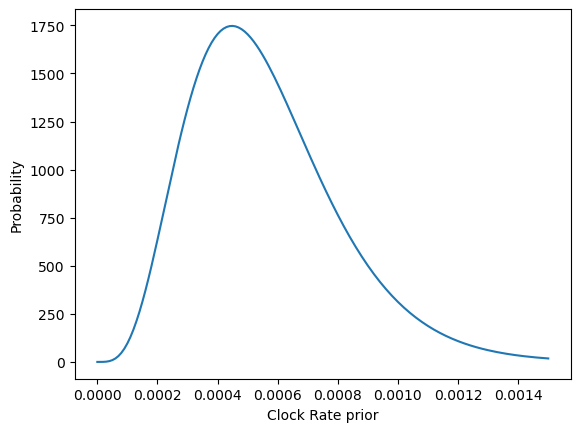

In [2]:
clock_rate_mean = np.median((5e-4,6.19e-4))
clock_rate_sd = 0.00025
clock_rate_gamma =  gamma_from_mean(mu=clock_rate_mean, sd=clock_rate_sd)
min_range = 0
max_range = 0.0015
step = 0.00001
xrange = np.arange(min_range, max_range + step, step=step)
probabilities = gamma.pdf(x=xrange, **clock_rate_gamma)
fig = plt.plot(xrange, probabilities)
plt.xlabel('Clock Rate prior')
plt.ylabel('Probability')

Parameters to beauti Input for gamma distributed clock rate pior.

In [3]:
clock_rate_gamma

{'a': np.float64(5.008644), 'scale': np.float64(0.00011170688114387846)}

In [4]:
clock_rate_mean

np.float64(0.0005595)

### HKY Substitution Model

HKY has been chosen as GTR was taking a long time converge. GTR has a considerable number parameters compared to HKY. The long convergence time due many parameters of GTR is seen with many viruses (COVID included). As such many reseachers studying viruses switch to HKY, even though GTR captures more of the underlying biology.

The settings for the HKY model are:
![image.png](hky_model.png)

The piors are not changed from the default.

## Models & Priors only found in the [Coalescent Exponential xml](Measles_coalescent_exp.xml).

The  population dynamics model in this xml has a single parameter, ePoPSize. The Prior for this is set at the default value.

## Models & Priors only found in the [BDSKY-Serial xml](Measles_BDKSY-Serial.xml).

This xml has a population dynamics model (Birth-Death Skyline, BDSky) with a number of parameters:
* Rate of becoming un-infectious (death rate). This in the inverse of the mean period from first infected to the end of a host transmitting.  **Note** BDSky has no latent infection (maturation period under a brith-death model).
* $R_e$ or $R_t$ (birth rate).
* Sampling proportion


## Rate of becoming un-infectious (death rate).

**Remember** this is the inverse of Mean Infection period (first infection to end of viremia), in years not days.


Lets begin by uploading the LSHTM R package epiparameter.

In [5]:
# To use the R Magic commands
import sys
import os
conda_env_path = sys.executable.replace("/bin/python","")
os.environ["R_HOME"] = f"{conda_env_path}/lib/R"
%load_ext rpy2.ipython

In [6]:
#R#  If you need to istall R's 'epiparameter' package unsilence code below:
#install.packages("epiparameter")

In [7]:
%%R -o measles_epi_params
library(epiparameter)
db <- epiparameter_db()
measles_epi_params <- parameter_tbl(multi_epiparameter = db, disease = "Measles")

Returning 125 results that match the criteria (100 are parameterised). 
Use subset to filter by entry variables or single_epiparameter to return a single entry. 
To retrieve the citation for each use the 'get_citation' function


In [8]:
measles_epi_params

,disease,pathogen,epi_name,prob_distribution,author,year,sample_size
1,Measles,Measles Virus,incubation period,lnorm,Lessler et al.,2009.0,55.0


Disease: Measles
Pathogen: Measles Virus
Epi Parameter: incubation period
Study: Lessler J, Reich N, Brookmeyer R, Perl T, Nelson K, Cummings D (2009).
“Incubation periods of acute respiratory viral infections: a systematic
review.” _The Lancet Infectious Diseases_.
doi:10.1016/S1473-3099(09)70069-12
<https://doi.org/10.1016/S1473-3099%2809%2970069-12>.
Distribution: lnorm (days)
Parameters:
  meanlog: 2.526
  sdlog: 0.207


Using Lessler J, Reich N, Brookmeyer R, Perl T, Nelson K, Cummings D (2009).
“Incubation periods of acute respiratory viral infections: a systematic
review.” _The Lancet Infectious Diseases_.
doi:10.1016/S1473-3099(09)70069-12
<https://doi.org/10.1016/S1473-3099%2809%2970069-12>.. 
To retrieve the citation use the 'get_citation' function


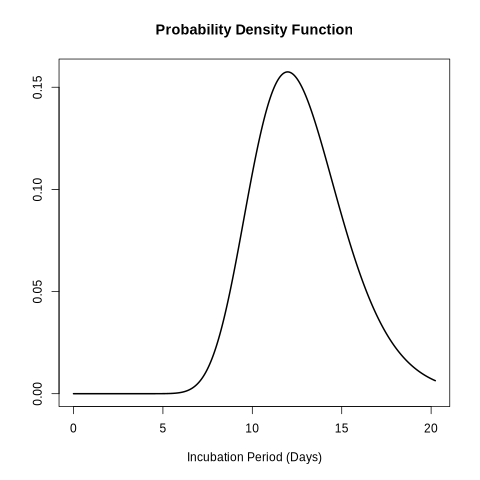

In [9]:
%%R -o measles_incubation
measles_incubation <- epiparameter_db(
  disease = "measles",
  epi_name = "incubation period",
  single_epiparameter = TRUE
)
plot(measles_incubation)
measles_incubation




As well as Lessler J et al (2009), above several public health agencies suggest an incubation period (time to onset of rash) of:
|     Source            |     Average (days)    |     Range (days)    |     URL  |
|----------------------|--------------------------|---------------------|------------|
|     PAHO              |     14                |     7 to 18         |     https://www.paho.org/en/topics/measles               |
|     WHO lab manual    |                       |     10 to 14        |     https://www.technet-21.org/en/manual-introduction/chapter-1-measles-and-rubella-an-overview/1-3-infection,-immune-response,-and-laboratory-diagnosis-of-measles    |
|     WHO website       |     14                |     7 to 18         |     https://www.who.int/news-room/fact-sheets/detail/measles#:~:text=The%20first%20sign%20of%20measles,develop%20in%20the%20initial%20stage.                       |
|     PHAC              |     14                |     7 to 21         |     https://www.canada.ca/en/public-health/services/diseases/measles/health-professionals-measles.html                |


The same agencies suggest a transmission period (days) post rash of
| Source         | Average (days) | Range (days) | URL  |
|----------------|----------------|--------------|--------------|
| PAHO           |                | -4 to 4      | https://www.paho.org/en/topics/measles     |
| WHO lab manual |                | -4 to 4      | https://www.technet-21.org/en/manual-introduction/chapter-1-measles-and-rubella-an-overview/1-3-infection,-immune-response,-and-laboratory-diagnosis-of-measles  |
| PHAC           |                | -4 to 4      | https://www.canada.ca/en/public-health/services/diseases/measles/health-professionals-measles.html   |


The paper below suggested a cultural viremia as high as 6-7 days post rash.
> Forthal, D.N. et al. (1992) “Degree and Length of Viremia in Adults with Measles,” The Journal of Infectious Diseases, 166(2), pp. 421–424. Available at: https://doi.org/10.1093/infdis/166.2.421.

Resus Maccac studies suggest a viremia could end as low as 14 days post infection:
> Lin, W.-H.W. et al. (2012) “Prolonged persistence of measles virus RNA is characteristic of primary infection dynamics,” Proceedings of the National Academy of Sciences, 109(37), pp. 14989–14994. Available at: https://doi.org/10.1073/pnas.1211138109.


This would give us an infectious period of about 14 to 28 days, mean 18.


Annoyingly BDSKY is not paramaterised with an infection period (life expectancy in days) but rate of becoming uninfectious (death rate in years).

Beast_pype some functions for working with with converting mean and sd to gamma distribution parameters and visulising between Infection period days and rate becoming uninfectious in years.



In [10]:
from beast_pype.stat_distributions import gamma_from_mean, gamma_df, plot_gamma_df

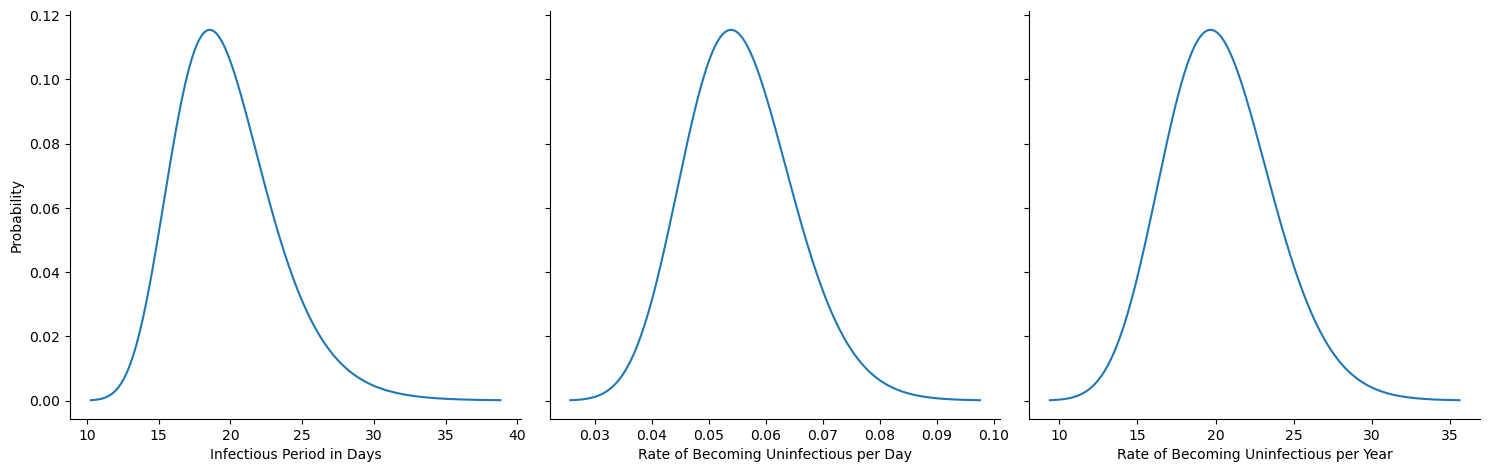

In [11]:
period_days = 18
period_years = period_days/365
rate_years = 1/period_years

gamma_fit = gamma_from_mean(rate_years, sd=3.5)
gamma_fit

df = gamma_df(**gamma_fit)
fig = plot_gamma_df(df)

In [12]:
rate_years

20.27777777777778

In [13]:
period_years

0.049315068493150684

Input for rate becoming uninfectious (gamma distributed prior) for bdsky serai in beauti.

In [14]:
gamma_fit

{'a': 33.56638951877047, 'scale': 0.6041095890410959}

## $R_e$

$R_e = S * R_0$ (Keeling & Rohani 2008, page 108) S being proportion susceptible. Therefore we need to look up $R_0$ and vaccination rate for Canada or the Americas.

### $R_0$
The following suggests that past Americas outbreaks of measles have had $R_0$ between 10.7-27.0, median 15.3.
> Guerra, F.M. et al. (2017) “The basic reproduction number (R0) of measles: a systematic review,” The Lancet Infectious Diseases, 17(12), pp. e420–e428. Available at: https://doi.org/10.1016/S1473-3099(17)30307-9.



### Proportion immune $1 - S$
A band for immunity from 88.3 to 93.1 % covers both:
> Osman, S. et al. (2022) “Population immunity to measles in Canada using Canadian Health Measures survey data – A Canadian Immunization Research Network (CIRN) study,” Vaccine, 40(23), pp. 3228–3235. Available at: https://doi.org/10.1016/j.vaccine.2022.04.011.
> [Highlights from the 2021 childhood National Immunization Coverage Survey (cNICS) - Canada.ca](https://www.canada.ca/en/public-health/services/immunization-vaccines/vaccination-coverage/2021-highlights-childhood-national-immunization-coverage-survey.html)

### Suggested $R_e$ prior

In [15]:
import numpy as np
from scipy.stats import gamma
from matplotlib import pyplot as plt
Re_max = 27*(1- 0.883)
Re_max

3.159

In [16]:
re_median = np.median((27,10.7))*np.median(((1- 0.883),(1- 0.931)))
re_median

np.float64(1.7530499999999996)

In [17]:
Re_min = 10.7*(1- 0.931)
Re_min

0.7382999999999994

Text(0, 0.5, 'Probability')

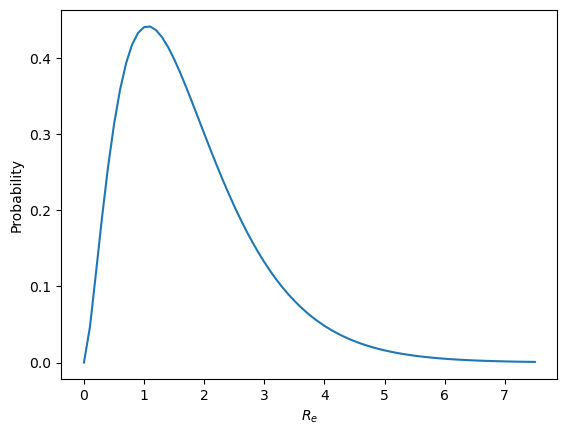

In [18]:
re_gamma_fit =  gamma_from_mean(1.753, sd=1.1)
min_range = 0
max_range = 7.5
step = 0.1
xrange = np.arange(min_range, max_range + step, step=step)
probabilities = gamma.pdf(x=xrange, **re_gamma_fit)
fig = plt.plot(xrange, probabilities)
plt.xlabel('$R_e$')
plt.ylabel('Probability')

Input for R_e (gamma distributed prior) for bdsky serai in beauti.

In [19]:
re_gamma_fit

{'a': 2.5396768595041315, 'scale': 0.690245293782088}

## Sampling Proportion

Outbreak DSID 4683 reported in Hiebert, J. et al. (2024) sequenced 39 out of 84 cases (0.4643).

> Hiebert, J. et al. (2024) “Genomic tools for post-elimination measles molecular epidemiology using Canadian surveillance data from 2018–2020,” Frontiers in Microbiology, 15. Available at: https://doi.org/10.3389/fmicb.2024.1475144.


Factors for a greater sampling proportion than 0.4643:
* Hiebert, J. et al. (2024) concerns largly pre-covid era sequencing. More sequencing is carried out post covid.

Factors tor a lesser sampling proportion than 0.4643:
* Denominator maybe slightly higher as some Measles cases maybe missed (some people may not come forward). **Note** Measles is a notifiable disease though so I am not sure how this is true.

Suggest using a broad beta distributed prior with mean/median around  0.4643.

![image.png](Sampling_proportion_prior.png)

Values of alpha=2 and beta = 2.5 seem to fit the bill.